# 병렬 노드 실행을 위한 분기 생성 방법

노드의 병렬 실행은 전체 그래프 작업의 속도를 향상시키는 데 필수적입니다. `LangGraph`는 노드의 병렬 실행을 기본적으로 지원하며, 이는 그래프 기반 워크플로우의 성능을 크게 향상시킬 수 있습니다. 

이러한 병렬화는 **fan-out**과 **fan-in** 메커니즘을 통해 구현되며, 표준 엣지와 `conditional_edges` 를 활용합니다. 

## 환경 설정

병렬 노드 실행 예제를 위한 환경을 설정합니다. 환경 변수를 로드하고 LangSmith 추적을 활성화합니다.

아래 코드에서는 환경 설정을 수행합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## 병렬 노드 fan-out 및 fan-in

**fan-out / fan-in**

병렬 처리에서 **fan-out**과 **fan-in**은 작업을 나누고 모으는 과정을 설명하는 개념입니다.

- **Fan-out (확장)**: 큰 작업을 여러 작은 작업으로 쪼갭니다. 예를 들어, 피자를 만들 때 도우, 소스, 치즈 준비를 각각 별도로 할 수 있습니다. 이렇게 각각의 파트를 나눠 동시에 처리하는 것이 fan-out입니다.

- **Fan-in (수집)**: 나뉜 작은 작업들을 다시 하나로 합칩니다. 피자에 준비된 재료들을 모두 올려 완성 피자를 만드는 과정처럼, 여러 작업이 끝나면 결과를 모아 최종 작업을 완성하는 것이 fan-in입니다.

즉, **fan-out**으로 작업을 분산시키고, **fan-in**으로 결과를 합쳐 최종 결과를 얻는 흐름입니다.

----

![](./assets/langgraph-09.jpeg)

이 예시에서는 `Node A`에서 `B and C`로 팬아웃하고 `D`로 팬인하는 과정을 보여줍니다. 

State에서는 `reducer(operator.add)` 연산자를 지정합니다. 이는 State 내 특정 키의 기존 값을 단순히 덮어쓰는 대신 값들을 결합하거나 누적합니다. 리스트의 경우, 새로운 리스트를 기존 리스트와 연결하는 것을 의미합니다.

LangGraph는 State의 특정 키에 대한 reducer 함수를 지정하기 위해 `Annotated` 타입을 사용합니다. 이는 타입 검사를 위해 원래 타입(`list`)을 유지하면서도, 타입 자체를 변경하지 않고 reducer 함수(`operator.add`)를 타입에 첨부할 수 있게 합니다.

> **참고**: `add_messages` 리듀서는 LangChain 메시지 객체 전용입니다. 단순 리스트 누적에는 `operator.add`를 사용합니다.

아래 코드에서는 State를 정의하고 A → (B, C) → D 구조의 fan-out/fan-in 그래프를 구성합니다.

In [3]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 상태 정의(operator.add 리듀서 사용: 리스트 누적)
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


# 노드 값 반환 클래스
class ReturnNodeValue:
    # 초기화
    def __init__(self, node_secret: str):
        self._value = node_secret

    # 호출시 상태 업데이트
    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


# 상태 그래프 초기화
builder = StateGraph(State)

# 노드 A부터 D까지 생성 및 값 할당
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_edge(START, "a")
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 노드 연결
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

# 그래프 컴파일
graph = builder.compile()

### 그래프 시각화

컴파일된 그래프를 시각화하여 A에서 B, C로 fan-out되고 D로 fan-in되는 구조를 확인합니다. B와 C는 병렬로 실행됩니다.

아래 코드는 그래프를 시각화합니다.

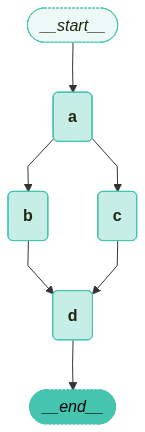

In [4]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

### 그래프 실행

그래프를 실행하여 각 노드에서 추가된 값들이 `operator.add` reducer를 통해 누적되는 것을 확인합니다. 실행 순서는 A → (B, C 병렬) → D 입니다.

아래 코드에서는 그래프를 실행하고 결과를 출력합니다.

In [5]:
# 그래프 실행
graph.invoke({"aggregate": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'aggregate': ["I'm A", "I'm B", "I'm C", "I'm D"]}

### 병렬처리 중 예외 발생시 대응

LangGraph는 "superstep(여러 노드들이 처리되는 전체 프로세스 스텝)" 내에서 노드를 실행하는데, 이는 병렬 분기가 동시에 실행되더라도 전체 superstep이 **트랜잭션** 방식으로 처리됨을 의미합니다. 

따라서, 이러한 분기 중 하나라도 예외가 발생하면, 상태에 대한 업데이트가 **전혀** 적용되지 않습니다(전체 superstep이 오류 처리됨).

> superstep: 여러 노드들이 처리되는 전체 프로세스 스텝

오류가 발생하기 쉬운 작업(예: 불안정한 API 호출 처리)이 있는 경우, LangGraph는 이를 해결하기 위한 두 가지 방법을 제공합니다.

1. 노드 내에서 일반적인 Python 코드를 작성하여 예외를 포착하고 처리할 수 있습니다.
2. **retry_policy** 를 설정하여 특정 유형의 예외가 발생한 노드를 재시도하도록 그래프를 지시할 수 있습니다. 실패한 분기만 재시도되므로 불필요한 작업 수행에 대해 걱정할 필요가 없습니다.

> 참고 문서: [LangGraph Use Graph API - Create Branches](https://docs.langchain.com/oss/python/langgraph/use-graph-api#create-branches)

이러한 기능들을 통해 병렬 실행과 예외 처리를 완벽하게 제어할 수 있습니다.

## 다단계 경로의 fan-out 및 fan-in

위의 예시에서는 각 경로가 단일 노드로 구성되었습니다. 하지만 실제 애플리케이션에서는 하나의 경로에 여러 단계가 있을 수 있습니다. 예를 들어 `b1 → b2` 경로와 `c` 경로가 병렬로 실행된 후 `d`에서 합쳐지는 구조입니다.

아래 코드에서는 다단계 경로를 포함한 fan-out/fan-in 그래프를 구현합니다.

In [6]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 상태 정의(operator.add 리듀서 사용: 리스트 누적)
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


# 노드 값 반환 클래스
class ReturnNodeValue:
    # 초기화
    def __init__(self, node_secret: str):
        self._value = node_secret

    # 호출시 상태 업데이트
    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


# 상태 그래프 초기화
builder = StateGraph(State)

# 노드 생성 및 연결
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_edge(START, "a")
builder.add_node("b1", ReturnNodeValue("I'm B1"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))
builder.add_edge("a", "b1")
builder.add_edge("a", "c")
builder.add_edge("b1", "b2")
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)

# 그래프 컴파일
graph = builder.compile()

### 그래프 시각화

다단계 경로가 포함된 그래프를 시각화합니다. `b1 → b2` 경로와 `c` 경로가 병렬로 실행된 후 `d`에서 합쳐지는 구조를 확인할 수 있습니다.

아래 코드는 그래프를 시각화합니다.

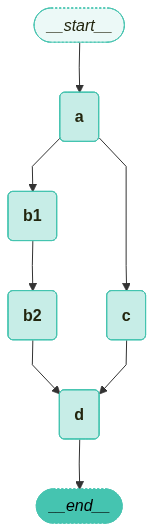

In [7]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

In [8]:
# 빈 리스트를 사용한 그래프 집계 연산 실행, 모든 데이터에 대한 기본 집계 수행
graph.invoke({"aggregate": []})

Adding I'm A to []
Adding I'm B1 to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B1", "I'm C"]
Adding I'm D to ["I'm A", "I'm B1", "I'm C", "I'm B2"]


{'aggregate': ["I'm A", "I'm B1", "I'm C", "I'm B2", "I'm D"]}

## 노드 실행 지연(Defer Node Execution)

앞선 다단계 경로 예시에서는 `add_edge(["b2", "c"], "d")` 구문을 사용하여 `d` 노드가 `b2`와 `c` 모두 완료된 후에 실행되도록 명시적으로 지정했습니다. 하지만 그래프가 복잡해지면 모든 선행 노드를 일일이 나열하기 어려울 수 있습니다.

LangGraph는 이러한 문제를 해결하기 위해 `defer=True` 옵션을 제공합니다. `add_node()` 에서 `defer=True` 를 설정하면, 해당 노드는 현재 진행 중인 **모든 대기 작업이 완료될 때까지** 실행을 지연합니다. 이를 통해 선행 노드를 명시적으로 나열하지 않아도, 모든 병렬 분기가 완료된 후에 노드가 실행되도록 보장할 수 있습니다.

이 기능은 특히 다음과 같은 상황에서 유용합니다.

- 병렬 분기의 길이가 서로 다른 경우
- 조건부 분기로 인해 어떤 노드가 실행될지 사전에 알 수 없는 경우
- map-reduce 패턴에서 모든 결과를 수집한 후 처리해야 하는 경우

> 참고 문서: [LangGraph Use Graph API - Defer Node Execution](https://docs.langchain.com/oss/python/langgraph/use-graph-api#defer-node-execution)

아래 코드에서는 `d` 노드에 `defer=True` 를 적용하여, `b1 → b2` 경로와 `c` 경로가 모두 완료된 후에 `d` 가 실행되는 그래프를 구현합니다.

In [9]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 상태 정의(operator.add 리듀서 사용: 리스트 누적)
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


# 노드 값 반환 클래스
class ReturnNodeValue:
    # 초기화
    def __init__(self, node_secret: str):
        self._value = node_secret

    # 호출시 상태 업데이트
    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


# 상태 그래프 초기화
builder = StateGraph(State)

# 노드 생성
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b1", ReturnNodeValue("I'm B1"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
# defer=True: 모든 대기 중인 작업이 완료될 때까지 실행을 지연
builder.add_node("d", ReturnNodeValue("I'm D"), defer=True)

# 노드 연결
builder.add_edge(START, "a")
builder.add_edge("a", "b1")
builder.add_edge("a", "c")
builder.add_edge("b1", "b2")
builder.add_edge("b2", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

# 그래프 컴파일
graph = builder.compile()

### 그래프 시각화

`defer=True` 가 적용된 그래프를 시각화합니다. 앞선 다단계 경로 예시와 동일한 구조이지만, `d` 노드가 지연 실행으로 설정되어 있어 모든 병렬 분기가 완료된 후에 실행됩니다.

아래 코드는 그래프를 시각화합니다.

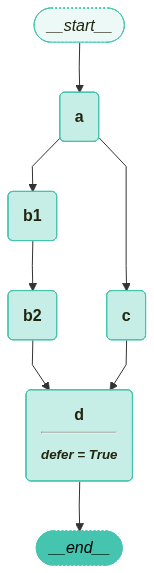

In [10]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

### 그래프 실행

그래프를 실행하여 `defer=True` 의 효과를 확인합니다. `d` 노드는 `c` 가 먼저 완료되더라도 `b2` 까지 완료될 때까지 기다린 후 실행됩니다.

앞선 다단계 경로 예시에서 `add_edge(["b2", "c"], "d")` 구문으로 달성했던 것과 동일한 동기화를, `defer=True` 한 줄로 간결하게 구현할 수 있습니다.

아래 코드에서는 그래프를 실행하고 결과를 출력합니다.

In [11]:
# 그래프 실행
graph.invoke({"aggregate": []})

Adding I'm A to []
Adding I'm B1 to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B1", "I'm C"]
Adding I'm D to ["I'm A", "I'm B1", "I'm C", "I'm B2"]


{'aggregate': ["I'm A", "I'm B1", "I'm C", "I'm B2", "I'm D"]}

## 조건부 분기(conditional branching)

fan-out이 결정적이지 않은 경우, `add_conditional_edges` 를 직접 사용하여 런타임에 분기 경로를 결정할 수 있습니다. 조건부 분기는 상태(State) 값에 따라 실행할 노드를 동적으로 선택하므로, 다양한 시나리오에 대응하는 유연한 워크플로우를 구성할 수 있습니다.

조건부 분기 이후 연결될 알려진 "sink" 노드가 있는 경우, 조건부 엣지를 생성할 때 `then="실행할 노드명"` 을 제공할 수 있습니다. 이를 사용하면 개별 엣지를 일일이 추가하지 않아도 됩니다.

> 참고 문서: [LangGraph Use Graph API - Conditional Branching](https://docs.langchain.com/oss/python/langgraph/use-graph-api#conditional-branching)

아래 코드에서는 `which` 상태 값에 따라 `b, c` 또는 `c, d`로 조건부 분기하는 그래프를 구현합니다.

In [12]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph


# 상태 정의(operator.add 리듀서 사용: 리스트 누적)
class State(TypedDict):
    aggregate: Annotated[list, operator.add]
    which: str


# 노드별 고유 값을 반환하는 클래스
class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


# 상태 그래프 초기화
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_edge(START, "a")
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))
builder.add_node("e", ReturnNodeValue("I'm E"))


# 상태의 'which' 값에 따른 조건부 라우팅 경로 결정 함수
def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]


# 전체 병렬 처리할 노드 목록
intermediates = ["b", "c", "d"]

builder.add_conditional_edges(
    "a",
    route_bc_or_cd,
    intermediates,
)
for node in intermediates:
    builder.add_edge(node, "e")


# 최종 노드 연결 및 그래프 컴파일
builder.add_edge("e", END)
graph = builder.compile()

### then 문법 사용

`add_conditional_edges`에서 `then` 파라미터를 사용하면 조건부 분기 이후 모든 경로가 공통으로 거쳐야 하는 노드를 지정할 수 있습니다. 이 경우 각 노드에서 해당 노드로의 엣지를 개별적으로 추가할 필요가 없어 코드가 더 간결해집니다.

아래는 `then` 문법을 사용한 참고 코드입니다.

In [13]:
## then 문법 사용시
# builder.add_conditional_edges(
#     "a",
#     route_bc_or_cd,
#     intermediates,
#     then="e",
# )

### 그래프 시각화

조건부 분기가 포함된 그래프를 시각화합니다. `which` 상태 값에 따라 `b, c` 또는 `c, d`로 분기한 후 `e`에서 합쳐지는 구조입니다.

아래 코드는 그래프를 시각화합니다.

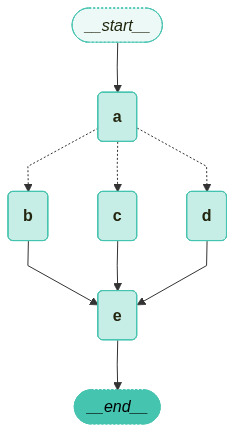

In [14]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

In [15]:
# 그래프 실행(which: bc 로 지정)
graph.invoke({"aggregate": [], "which": "bc"})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm E to ["I'm A", "I'm B", "I'm C"]


{'aggregate': ["I'm A", "I'm B", "I'm C", "I'm E"], 'which': 'bc'}

In [16]:
# 그래프 실행(which: cd 로 지정)
graph.invoke({"aggregate": [], "which": "cd"})

Adding I'm A to []
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A"]
Adding I'm E to ["I'm A", "I'm C", "I'm D"]


{'aggregate': ["I'm A", "I'm C", "I'm D", "I'm E"], 'which': 'cd'}

## fan-out 값의 신뢰도에 따른 정렬

병렬로 펼쳐진 노드들은 하나의 "**super-step**"으로 실행됩니다. 각 super-step 에서 발생한 업데이트들은 해당 super-step 이 완료된 후 순차적으로 상태에 적용됩니다.

병렬 super-step 에서 일관된 사전 정의된 업데이트 순서가 필요한 경우, 출력값을 식별 키와 함께 상태의 별도 필드에 기록한 다음, 팬아웃된 각 노드에서 집결 지점까지 일반 `edge` 를 추가하여 "sink" 노드에서 이들을 결합해야 합니다.

아래 코드에서는 병렬 단계의 출력을 "신뢰도(reliability)"에 따라 정렬하는 예시를 구현합니다.

In [17]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 팬아웃 값들의 병합 로직 구현, 빈 리스트 처리 및 리스트 연결 수행
def reduce_fanouts(left, right):
    if left is None:
        left = []
    if not right:
        # 덮어쓰기
        return []
    return left + right


# 상태 관리를 위한 타입 정의, 집계 및 팬아웃 값 저장 구조 설정
class State(TypedDict):
    # operator.add 리듀서 사용: 리스트 누적
    aggregate: Annotated[list, operator.add]
    fanout_values: Annotated[list, reduce_fanouts]
    which: str


# 그래프 초기화
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_edge(START, "a")


# 병렬 노드 값 반환 클래스
class ParallelReturnNodeValue:
    def __init__(
        self,
        node_secret: str,
        reliability: float,
    ):
        self._value = node_secret
        self._reliability = reliability

    # 호출시 상태 업데이트
    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']} in parallel.")
        return {
            "fanout_values": [
                {
                    "value": [self._value],
                    "reliability": self._reliability,
                }
            ]
        }


# 신뢰도(reliability)가 다른 병렬 노드들 추가
builder.add_node("b", ParallelReturnNodeValue("I'm B", reliability=0.1))
builder.add_node("c", ParallelReturnNodeValue("I'm C", reliability=0.9))
builder.add_node("d", ParallelReturnNodeValue("I'm D", reliability=0.5))


# 팬아웃 값들을 신뢰도 기준으로 정렬하고 최종 집계 수행
def aggregate_fanout_values(state: State) -> Any:
    # 신뢰도 기준 정렬
    ranked_values = sorted(
        state["fanout_values"], key=lambda x: x["reliability"], reverse=True
    )
    print(ranked_values)
    return {
        "aggregate": [x["value"][0] for x in ranked_values] + ["I'm E"],
        "fanout_values": [],
    }


# 집계 노드 추가
builder.add_node("e", aggregate_fanout_values)


# 상태에 따른 조건부 라우팅 로직 구현
def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]


# 중간 노드들 설정 및 조건부 엣지 추가
intermediates = ["b", "c", "d"]
builder.add_conditional_edges("a", route_bc_or_cd, intermediates)

# 중간 노드들과 최종 집계 노드 연결
for node in intermediates:
    builder.add_edge(node, "e")

# 그래프 완성을 위한 최종 노드 연결
builder.add_edge("e", END)
graph = builder.compile()

### 그래프 시각화

신뢰도 기반 정렬이 포함된 그래프를 시각화합니다. 병렬 노드들의 결과가 `fanout_values`에 저장되고, `e` 노드에서 신뢰도 순으로 정렬되어 최종 결과에 반영됩니다.

아래 코드는 그래프를 시각화합니다.

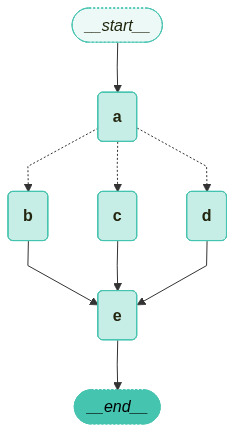

In [18]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

### 신뢰도 기반 정렬 테스트

병렬로 실행된 노드들의 결과가 신뢰도(reliability) 기준으로 정렬되는 것을 확인합니다. `which="bc"`인 경우 B(0.1)와 C(0.9)가 실행되고, C가 더 높은 신뢰도를 가지므로 결과에서 먼저 나타납니다.

- `b`: reliability=0.1
- `c`: reliability=0.9
- `d`: reliability=0.5

아래 코드에서는 다른 `which` 값으로 그래프를 실행하여 결과를 비교합니다.

In [19]:
# 그래프 실행(which: bc 로 지정)
graph.invoke({"aggregate": [], "which": "bc", "fanout_values": []})

Adding I'm A to []
Adding I'm B to ["I'm A"] in parallel.
Adding I'm C to ["I'm A"] in parallel.
[{'value': ["I'm C"], 'reliability': 0.9}, {'value': ["I'm B"], 'reliability': 0.1}]


{'aggregate': ["I'm A", "I'm C", "I'm B", "I'm E"],
 'fanout_values': [],
 'which': 'bc'}

In [20]:
# 그래프 실행(which: cd 로 지정)
graph.invoke({"aggregate": [], "which": "cd"})

Adding I'm A to []
Adding I'm C to ["I'm A"] in parallel.
Adding I'm D to ["I'm A"] in parallel.
[{'value': ["I'm C"], 'reliability': 0.9}, {'value': ["I'm D"], 'reliability': 0.5}]


{'aggregate': ["I'm A", "I'm C", "I'm D", "I'm E"],
 'fanout_values': [],
 'which': 'cd'}